# Assignment Code: DA-AG-018
# Anomaly Detection & Time Series | Assignment

**Q1.** What is Anomaly Detection? Explain its types (point, contextual, and collective anomalies) with examples.

- **Ans:** **Anomaly Detection** is the process of identifying data points, events, or observations that deviate significantly from the normal pattern in a dataset.

- **Types of Anomalies**
 - **Point Anomalies:**
    - A single data point that is significantly different from the rest.
    - Example: A sudden credit card charge of $5,000 when typical transactions are below $100.
 - **Contextual Anomalies:**
    - A data point that is anomalous only within a specific context (time, location, etc.).
    - Example: A temperature of 30°C is normal in summer but abnormal in winter.
 - **Collective Anomalies:**
    - A group of related data points that together form an abnormal pattern, even if individual points appear normal.
    - Example: A sequence of unusual network packets indicating a cyberattack.


**Q2.** Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.

- **Ans:** **Isolation Forest**
   - Approach: Detects anomalies by randomly isolating data points; anomalies require fewer splits to isolate.
   - Use Cases: Large and high-dimensional datasets; general-purpose anomaly detection.
- **DBSCAN**
  - Approach: Density-based clustering; points in low-density regions are labeled as outliers.
  - Use Cases: Spatial or irregularly shaped data; detecting noise during clustering.
- **Local Outlier Factor (LOF)**
  - Approach: Measures local density deviation relative to neighbors; lower-density points are flagged as outliers.
  - Use Cases: Datasets with varying local densities; identification of localized anomalies.

**Q3.** What are the key components of a Time Series? Explain each with one example.

- **Ans:** **Key Components of a Time Series**
  - **Trend:** Long-term directional movement in the data.
    - Example: A steady increase in annual sales.
  - **Seasonality:** Regular, repeating patterns at fixed intervals.
    - Example: Higher retail sales during holidays.
  - **Cyclic Component:** Long-term fluctuations without fixed periodicity.
    - Example: Multi-year economic booms and recessions.
  - **Irregular Component:** Random, unpredictable variations.
    - Example: A sudden drop in demand due to an unexpected event.


**Q4.** Define Stationary in time series. How can you test and transform a non-stationary series into a stationary one?

- **Ans:** **Stationarity:** A time series is stationary when its mean, variance, and autocovariance remain constant over time.
- **Testing for Stationarity**
  - Statistical tests: Augmented Dickey-Fuller (ADF), KPSS.
  - Visual checks: IDentifying trends or changing variance in plots.
- **Transforming a Non-Stationary Series**
  - Differencing to remove trends.
  - Deseasonalization to eliminate seasonal effects.
  - Detrending or transformations (e.g., log or Box-Cox) to stabilize variance.


**Q5.** Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in terms of structure and application.

- **Ans:** **AR (Autoregressive)**
  - Uses past values of the series for prediction.
  - Use: Data with strong autocorrelation.

- **MA (Moving Average)**
  - Uses past error teams for prediction.
  - Use: Data where shocks or noise affect future values.

- **ARIMA**
  - Combines AR and MA with differencing to address non-stationarity.
  - Use: Non-seasonal time series forecasting.
- **SARIMA**
   - Extends ARIMA with seasonal AR, I, and MA components.
   - Use: Time series with clear seasonal patterns.       
- **SARIMAX**
   - Adds exogenous (external) variables to SARIMA.
   - Use: Seasonal series influenced by external factors.









**Q10.** You are working as a data scientist for a power grid monitoring company. Your goal is to forecast energy demand and also detect abnormal spikes or drops in real-time consumption data collected every 15 minutes. The dataset includes features like timestamp, region, weather conditions, and energy usage.

* Explain your real-time data science workflow:
   * How would you detect anomalies in this streaming data (Isolation Forest / LOF / DBSCAN)?
   * Which time series model would you use for short-term forecasting (ARIMA / SARIMA / SARIMAX)?
   * How would you validate and monitor the performance over time?
   * How would this solution help business decisions or operations?

- **Ans:** **Real-Time Energy Demand Forecasting and Anomaly Detection**
  - **Anomaly Detection**
      - Use Isolation Forest or LOF on a rolling window of 15-minute consumption data.
      - Detect sudden spikes or drops in real-time and trigger alerts.
  - **Time Series Forecasting**
      - Apply SARIMAX to model trend, seasonality, and external factors (weather, region).
      - Generate short-term forecasts (next 1-4 hours) for operational planning.
  - **Validation and Monitoring**
      - Backtesting using historical data with metrics like MAE or RMSE.
      - Monitor forecast drift and anomaly detection rates; update models periodically.
  - **Business Impact**
      - Operational efficiency: Prevent overloads and optimize energy distribution.
      - Resource planning: Inform staffing, procurement, and load balancing.
      - Decision support: Real-time alerts guide proactive maintenance and strategy.




In [ ]:

# Dataset:
 # - NYC Taxi Fare Data
 # - AirPassengers Dataset
import warnings
warnings.filterwarnings("ignore")

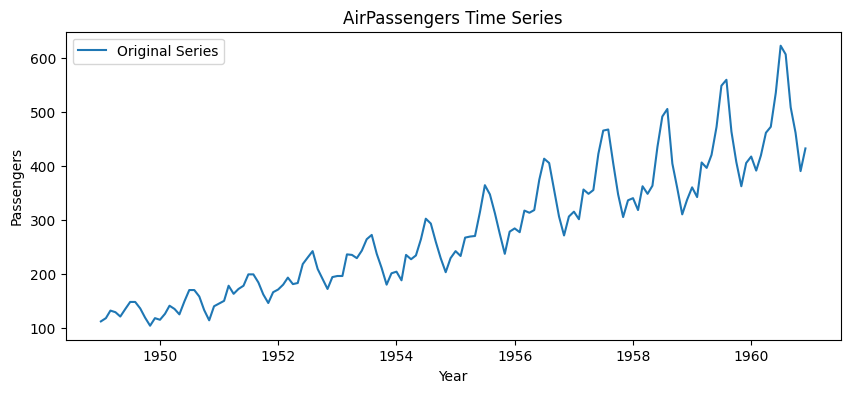

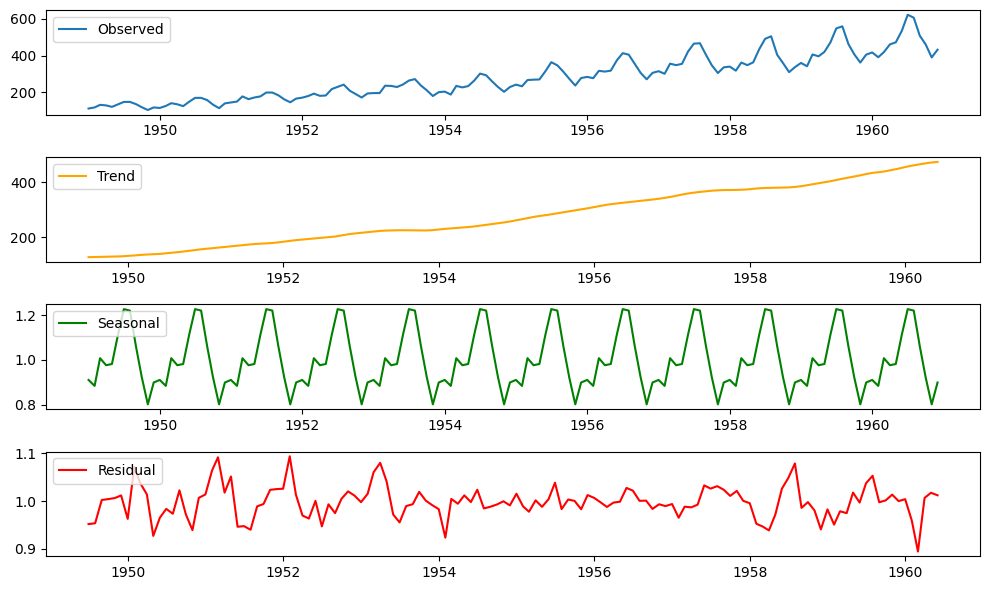

In [7]:
# Q6. Load a time series dataset (e.g., AirPassengers), plot the original series, and decompose it into trend, seasonality, and residual components

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load the AirPassengers dataset
data = pd.read_csv('AirPassengers.csv', parse_dates=['Month'], index_col='Month')

# Plot the original time series
plt.figure(figsize=(10,4))
plt.plot(data, label='Original Series')
plt.title('AirPassengers Time Series')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.legend()
plt.show()

# Decompose the time series
decomposition = seasonal_decompose(data['#Passengers'], model='multiplicative', period=12)

# Plot the decomposed components
plt.figure(figsize=(10,6))
plt.subplot(411)
plt.plot(decomposition.observed, label='Observed')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='orange')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal', color='green')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(decomposition.resid, label='Residual', color='red')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

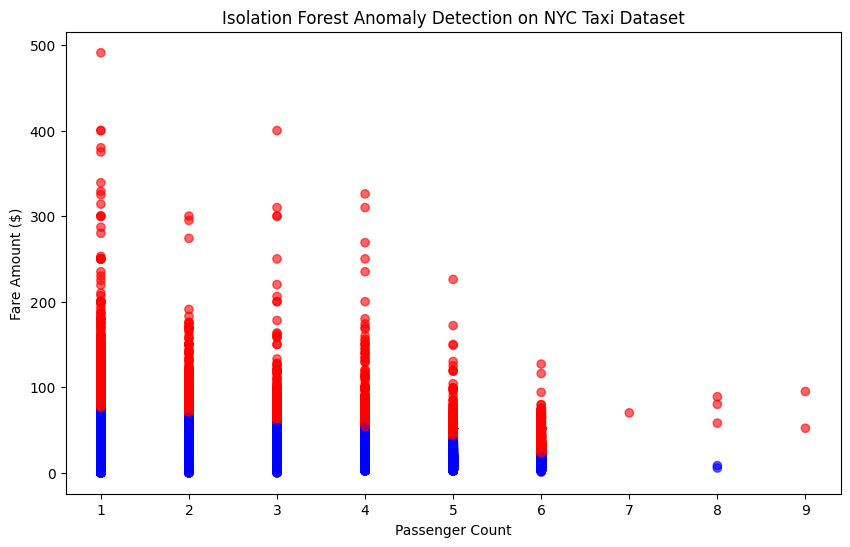

In [ ]:
# Q7. Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to detect anomalies. Visualize the anomalies on a 2D scatter plot.

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Load dataset
data = pd.read_csv('NYC_taxi_fare_data.csv')

# Select features and clean data
df = data[['passenger_count', 'fare_amount']].dropna()
df = df[(df['fare_amount'] > 0) & (df['passenger_count'] > 0)]

# Intialize Isolation Forest
iso_forest = IsolationForest(contamination=0.01, random_state=42)
df['anomaly'] = iso_forest.fit_predict(df)
df['anomaly_label'] = df['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

# Plot Anomalies
plt.figure(figsize=(10,6))
colors = {'Normal':'blue', 'Anomaly':'red'}
plt.scatter(df['passenger_count'], df['fare_amount'], c=df['anomaly_label'].map(colors), alpha=0.6)
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount ($)')
plt.title('Isolation Forest Anomaly Detection on NYC Taxi Dataset')
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


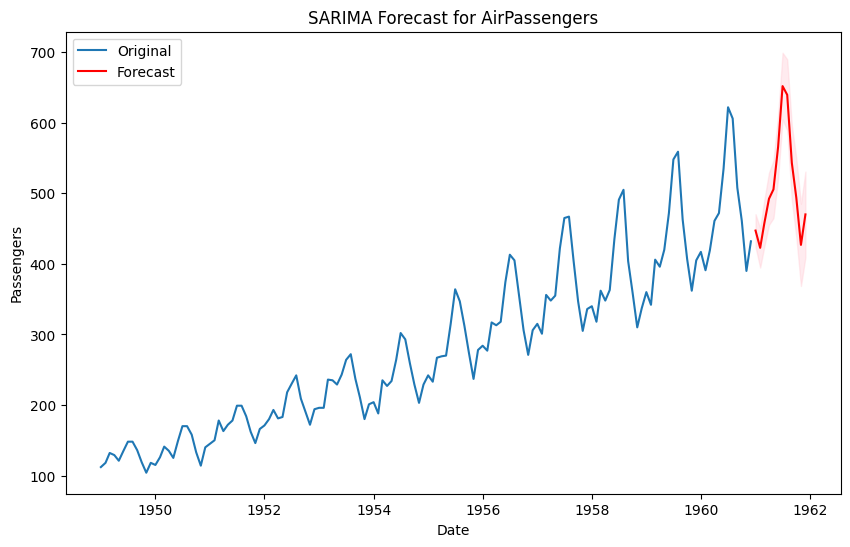

In [ ]:
# Q8. Train a SARIMA model on the monthly airline passengers dataset. Forecast the next 12 months and visualize the results.

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load the AirPassengers dataset
data = pd.read_csv('AirPassengers.csv', parse_dates=['Month'], index_col='Month')

# Fit SARIMA model (p,d,q)(P,D,Q,s)
# Common parameters for AirPassengers: (1,1,1)(1,1,1,12)
sarima_model = SARIMAX(data['#Passengers'],
                       order=(1,1,1),
                       seasonal_order=(1,1,1,12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_result = sarima_model.fit()

# Forecast next 12 months
forecast = sarima_result.get_forecast(steps=12)
forecast_index = pd.date_range(start=data.index[-1] + pd.offsets.MonthBegin(),
                               periods=12, freq='MS')
forecast_series = pd.Series(forecast.predicted_mean.values, index=forecast_index)
confidence_intervals = forecast.conf_int()

# Plot original series and forecast
plt.figure(figsize=(10,6))
plt.plot(data['#Passengers'], label='Original')
plt.plot(forecast_series, label='Forecast', color='red')
plt.fill_between(forecast_index,
                 confidence_intervals.iloc[:,0],
                 confidence_intervals.iloc[:,1],
                 color='pink', alpha=0.3)
plt.title('SARIMA Forecast for AirPassengers')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()

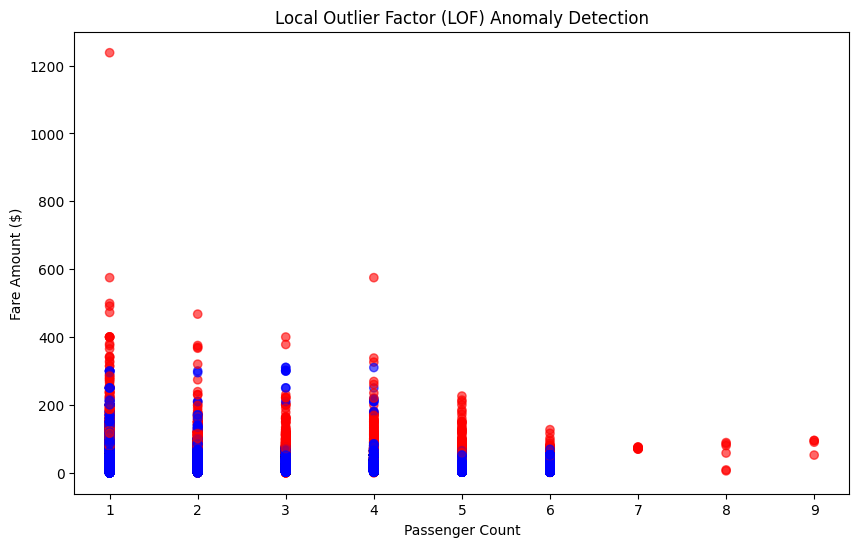

In [6]:
# Q9. Apply Local Outlier Factor (LOF) on any numerical dataset to detect anomalies and visualize them using matplotlib.


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

# Load a sample numerical dataset (replace with your CSV if needed)
# For example, using NYC Taxi dataset
data = pd.read_csv('NYC_taxi_fare_data.csv')

# Select two numerical features for 2D visualization
df = data[['passenger_count', 'fare_amount']].dropna()
df = df[(df['fare_amount'] > 0) & (df['passenger_count'] > 0)]  # Clean unrealistic values

# Apply Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
df['anomaly'] = lof.fit_predict(df)
df['anomaly_label'] = df['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

# Visualize anomalies
plt.figure(figsize=(10,6))
colors = {'Normal':'blue', 'Anomaly':'red'}
plt.scatter(df['passenger_count'], df['fare_amount'], c=df['anomaly_label'].map(colors), alpha=0.6)
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount ($)')
plt.title('Local Outlier Factor (LOF) Anomaly Detection')
plt.show()
